# CNN vs Vision Transformer vs Mamba/SSM en Fashion-MNIST

Este notebook compara **tres paradigmas de visión artificial** sobre **la misma tarea**:

1. **CNN clásica**
2. **Vision Transformer (ViT) minimal**
3. **Modelo tipo Mamba / SSM minimal** *(opcional / avanzado)*

## Objetivos

- Ver que **la misma tarea** puede resolverse con arquitecturas diferentes.
- Entender qué cambia entre **convolución**, **atención** y **modelado secuencial eficiente**.
- Comparar:
  - rendimiento
  - coste conceptual
  - facilidad de explicación
  - adecuación según el problema

> Recomendación didáctica: usar primero la CNN como baseline, luego el ViT como “avance” y dejar SSM/Mamba como extensión opcional.


## 0. Idea general

### CNN
- Aprende **filtros locales**
- Comparte pesos
- Tiene **sesgos inductivos fuertes** para imágenes

### Vision Transformer (ViT)
- Divide la imagen en **patches**
- Usa **autoatención**
- Modela relaciones **globales**

### Mamba / SSM
- Trata la entrada como **secuencia**
- Sustituye parte o toda la atención por **dinámicas de estado**
- Busca **eficiencia lineal** y menor coste de memoria


In [16]:
import os
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)
print("KERAS_BACKEND:", os.environ.get("KERAS_BACKEND"))


TensorFlow: 2.20.0
KERAS_BACKEND: tensorflow


## 1. Carga y preparación del dataset

In [17]:
dataset_candidates = [
    Path("../data/oxford_flowers102/oxford_flowers102_64x64_rgb.npz"),
    Path("data/oxford_flowers102/oxford_flowers102_64x64_rgb.npz"),
    Path("/kaggle/input/oxford-flowers-102-prepared/oxford_flowers102_64x64_rgb.npz"),
    Path("/kaggle/input/oxford-flowers-102/oxford_flowers102_64x64_rgb.npz"),
    Path("/content/oxford_flowers102_64x64_rgb.npz"),
    Path("/content/data/oxford_flowers102/oxford_flowers102_64x64_rgb.npz"),
    Path("/content/drive/MyDrive/oxford_flowers102_64x64_rgb.npz"),
    Path("/content/drive/MyDrive/data/oxford_flowers102/oxford_flowers102_64x64_rgb.npz"),
]

dataset_path = next((path for path in dataset_candidates if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        "No se encuentra oxford_flowers102_64x64_rgb.npz en ninguna ruta conocida. "
        "Subelo al entorno o ajusta dataset_candidates."
    )

dataset = np.load(dataset_path, allow_pickle=True)

x_train = dataset["x_train"].astype("float32")
x_test = dataset["x_test"].astype("float32")
y_train = dataset["y_train"].astype("int64")
y_test = dataset["y_test"].astype("int64")

x_train_img = x_train if x_train.ndim == 4 else x_train[..., None]
x_test_img = x_test if x_test.ndim == 4 else x_test[..., None]

image_shape = x_train_img.shape[1:]
image_height, image_width, image_channels = image_shape
flat_tokens = image_height * image_width

train_epochs = 12
train_batch_size = 32
train_validation_split = 0.15

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
)

class_names = dataset["class_names"].tolist()
num_classes = len(class_names)

print("Dataset:", dataset_path)
print("Train:", x_train_img.shape, y_train.shape)
print("Test :", x_test_img.shape, y_test.shape)
print("Image shape:", image_shape)
print("Classes:", num_classes)
print("Training:", {"epochs": train_epochs, "batch_size": train_batch_size, "validation_split": train_validation_split})


Dataset: ../data/oxford_flowers102/oxford_flowers102_64x64_rgb.npz
Train: (2040, 64, 64, 3) (2040,)
Test : (6149, 64, 64, 3) (6149,)
Image shape: (64, 64, 3)
Classes: 102
Training: {'epochs': 12, 'batch_size': 32, 'validation_split': 0.15}


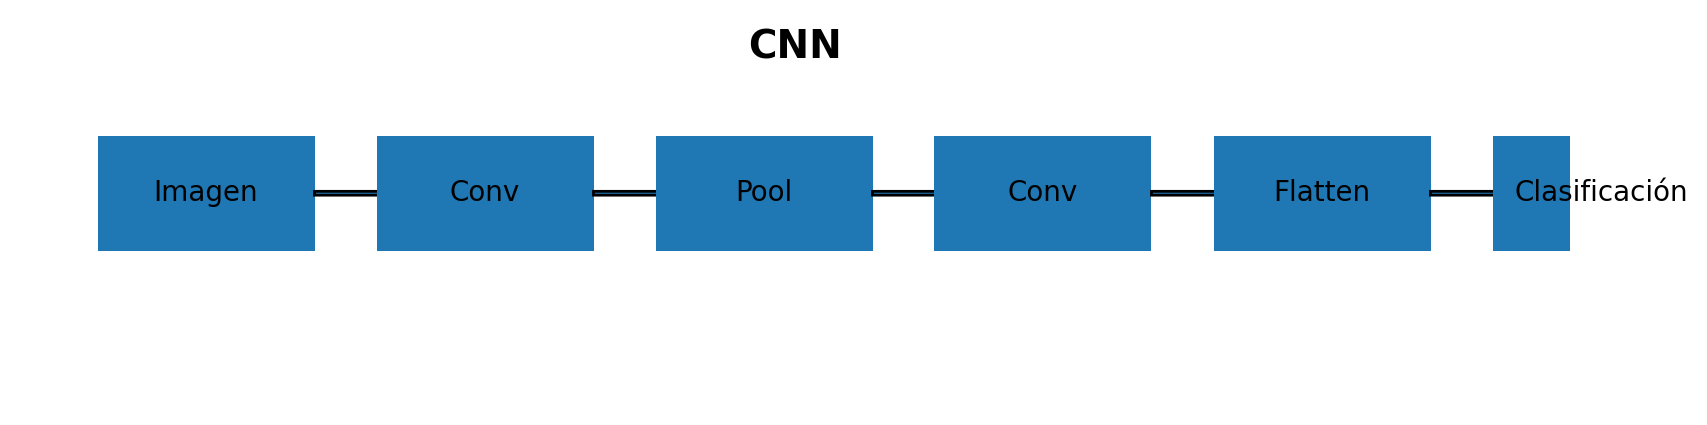

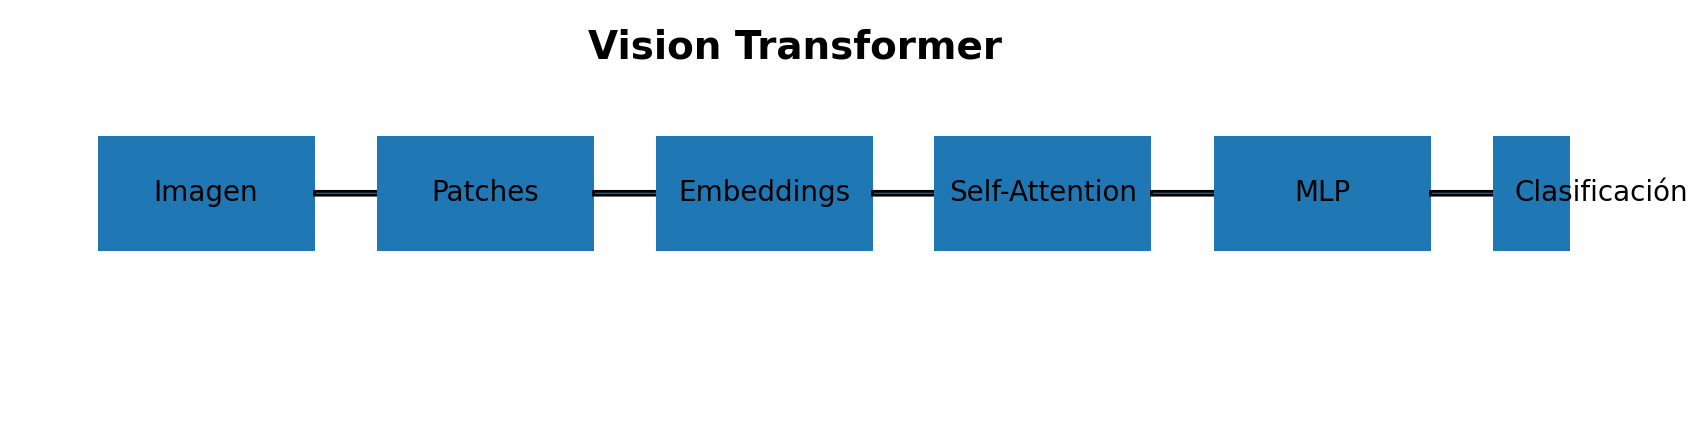

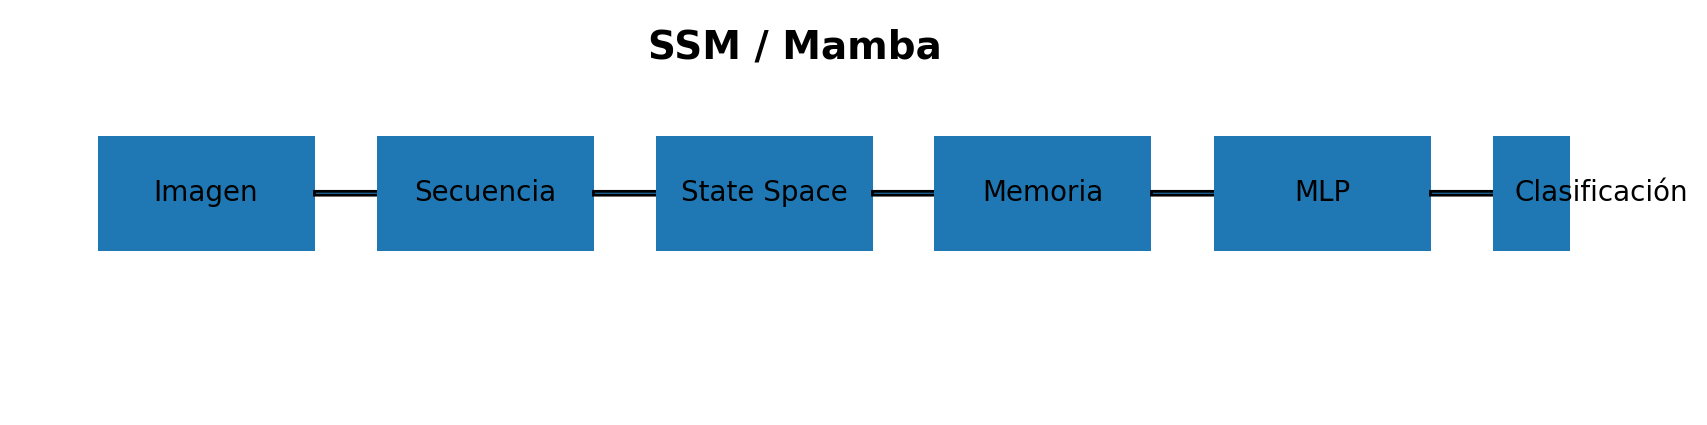

In [1]:
from IPython.display import Image, display

display(Image("cnn_pipeline.png"))
display(Image("vit_pipeline.png"))
display(Image("mamba_pipeline.png"))


In [ ]:
plt.figure(figsize=(10,4))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train_img[i].squeeze(), cmap="gray" if image_channels == 1 else None)
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 2. Baseline — CNN clásica

Esta es la arquitectura más natural para empezar en visión:
- Conv2D
- MaxPooling
- Conv2D
- MaxPooling
- Flatten
- Capas densas


In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=image_shape),
    data_augmentation,
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


In [ ]:
cnn_history = cnn_model.fit(
    x_train_img, y_train,
    validation_split=train_validation_split,
    epochs=train_epochs,
    batch_size=train_batch_size,
    callbacks=[early_stopping],
    verbose=1
)


### Evaluación CNN

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_img, y_test, verbose=0)
print("CNN test accuracy:", cnn_test_acc)


## 3. Vision Transformer (ViT) minimal

Aquí tratamos la imagen como una **secuencia de patches**.

### Pipeline
1. Dividir imagen en patches
2. Aplanar patches
3. Proyectarlos a embeddings
4. Añadir embeddings posicionales
5. Pasarlos por bloques Transformer
6. Clasificar


In [18]:
patch_size = 8
num_patches = (image_height // patch_size) * (image_width // patch_size)
projection_dim = 96
num_heads = 4
transformer_layers = 3

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def create_vit_classifier():
    inputs = layers.Input(shape=image_shape)
    augmented = data_augmentation(inputs)
    patches = Patches(patch_size)(augmented)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=[projection_dim * 2, projection_dim], dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.3)(representation)
    features = mlp(representation, hidden_units=[256, 128], dropout_rate=0.2)
    logits = layers.Dense(num_classes, activation="softmax")(features)

    return tf.keras.Model(inputs=inputs, outputs=logits)

vit_model = create_vit_classifier()
vit_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 64, 64, 3) │          0 │ input_layer_3[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, None, 192) │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_1     │ (None, 64, 96)    │     24,672 │ patches_1[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 96)    │        192 │ patch_encoder_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 96)    │    148,704 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 64, 96)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 96)    │        192 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64, 192)   │     18,624 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64, 192)   │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64, 96)    │     18,528 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64, 96)    │          0 │ dense_14[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 64, 96)    │          0 │ dropout_16[0][0], │
│                     │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 96)    │        192 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 96)    │    148,704 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 64, 96)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 96)    │        192 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64, 192)   │     18,624 │ layer_normalizat

 Total params: 2,202,758 (8.40 MB)

 Trainable params: 2,202,758 (8.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
vit_history = vit_model.fit(
    x_train_img, y_train,
    validation_split=train_validation_split,
    epochs=train_epochs,
    batch_size=train_batch_size,
    callbacks=[early_stopping],
    verbose=1
)


### Evaluación ViT

In [ ]:
vit_test_loss, vit_test_acc = vit_model.evaluate(x_test_img, y_test, verbose=0)
print("ViT test accuracy:", vit_test_acc)


## 4. Modelo tipo Mamba / SSM minimal (opcional)

Esto es un **avance** de arquitecturas modernas que intentan evitar el coste cuadrático de la atención.

### Idea
- Reordenar la imagen como secuencia
- Procesarla con una capa tipo **State Space Model**
- Mantener un coste más eficiente

> Nota: la disponibilidad depende de si tienes `keras_hub` y su capa SSM en tu entorno.


In [2]:
# Intentamos usar keras_hub si está disponible
try:
    import keras_hub
    HAS_KERAS_HUB = True
except Exception:
    HAS_KERAS_HUB = False
    keras_hub = None

HAS_STATE_SPACE_MODEL = HAS_KERAS_HUB and hasattr(keras_hub.layers, "StateSpaceModel")
print("keras_hub disponible:", HAS_KERAS_HUB)
print("StateSpaceModel disponible:", HAS_STATE_SPACE_MODEL)


2026-03-09 03:09:50.350057: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/jmsa/mambaforge/envs/pia-ud1/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/jmsa/mambaforge/envs/pia-ud1/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in

keras_hub disponible: True
StateSpaceModel disponible: False


In [3]:
keras_hub.__version__

'0.26.0'

In [20]:
if HAS_STATE_SPACE_MODEL:
    ssm_inputs = layers.Input(shape=image_shape)
    augmented = data_augmentation(ssm_inputs)
    x = layers.Reshape((flat_tokens, image_channels))(augmented)

    x = keras_hub.layers.StateSpaceModel(
        units=64,
        kernel_size=16,
        activation="gelu"
    )(x)

    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.25)(x)
    ssm_outputs = layers.Dense(num_classes, activation="softmax")(x)

    ssm_model = tf.keras.Model(ssm_inputs, ssm_outputs)
    ssm_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    ssm_model.summary()
else:
    print("No se puede construir el modelo SSM en este entorno.")


No se puede construir el modelo SSM en este entorno.


In [ ]:
if HAS_STATE_SPACE_MODEL:
    ssm_history = ssm_model.fit(
        x_train_img, y_train,
        validation_split=train_validation_split,
        epochs=train_epochs,
        batch_size=train_batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    ssm_test_loss, ssm_test_acc = ssm_model.evaluate(x_test_img, y_test, verbose=0)
    print("SSM/Mamba-like test accuracy:", ssm_test_acc)
else:
    print("Se omite entrenamiento SSM en este entorno.")


## 5. Comparativa de curvas de entrenamiento

Si algún modelo no se ha podido entrenar, simplemente compara CNN y ViT.


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(cnn_history.history["val_accuracy"], label="CNN")
plt.plot(vit_history.history["val_accuracy"], label="ViT")
if "ssm_history" in globals():
    plt.plot(ssm_history.history["val_accuracy"], label="SSM/Mamba-like")
plt.title("Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(cnn_history.history["val_loss"], label="CNN")
plt.plot(vit_history.history["val_loss"], label="ViT")
if "ssm_history" in globals():
    plt.plot(ssm_history.history["val_loss"], label="SSM/Mamba-like")
plt.title("Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


## 6. Tabla de resultados

Interpretación rápida:
- **CNN**: muy buena baseline, eficiente y fácil de explicar.
- **ViT**: más flexible, más “global”, pero suele necesitar más datos para brillar.
- **SSM/Mamba-like**: muy prometedor en eficiencia, todavía menos estándar en docencia inicial.


In [ ]:
results = {
    "CNN": cnn_test_acc,
    "ViT": vit_test_acc,
}

if "ssm_test_acc" in globals():
    results["SSM/Mamba-like"] = ssm_test_acc

for name, acc in results.items():
    print(f"{name:20s} -> test_acc = {acc:.4f}")


## 7. Conclusiones didácticas

### ¿Qué enseñar primero?
- **Primero CNN**
- Luego **ViT como avance**
- Y **SSM/Mamba** como extensión opcional

### Mensaje clave para el alumnado
No hay una única arquitectura “ganadora” universal:

- **CNN**: fuertes sesgos inductivos, buena con pocos datos
- **ViT**: menos sesgo inductivo, mejor con datos masivos
- **SSM/Mamba**: busca eficiencia y memoria lineal

### Preguntas para clase
1. ¿Por qué la CNN suele ser más fácil de entrenar aquí?
2. ¿Qué gana un ViT al trabajar por patches?
3. ¿Qué problema intenta resolver un modelo tipo Mamba?
4. ¿Qué arquitectura usarías en un móvil? ¿Y en un gran cluster?
